# Local Projections

This notebook introduces `statsmodels.tsa.vector_ar.local_proj.LocalProjections`, which estimates impulse response functions (IRFs) using the *local projections* (LP) method of Jordà (2005). LP is the standard nonparametric alternative to the usual VAR-based approach to IRF estimation: instead of fitting a single VAR and inverting it into its moving-average representation, LP runs a *separate* OLS regression for each horizon $h$,

$$
y_{t+h} = \alpha_h + \beta_h z_t + \Gamma_h x_t + \varepsilon_{t+h},
\qquad h = 0, 1, \ldots, H,
$$

where $z_t$ is the shock variable and $x_t$ are lagged controls. The sequence of estimated $\hat\beta_h$ coefficients *is* the impulse response function. Because each horizon is estimated on its own, LP avoids propagating a single (possibly misspecified) lag structure across every horizon the way an iterated VAR forecast does, at some cost in efficiency. Standard errors are Newey-West HAC-corrected, since the $h$-step-ahead residuals are an MA($h$) process by construction.

As an application, we estimate the dynamic response of output, consumption and investment to a government spending shock -- a classic *fiscal multiplier* question, and one of the settings local projections are most commonly used for in applied macroeconomics.

**Reference**: Jordà, Ò. (2005). Estimation and Inference of Impulse Responses by Local Projections. *American Economic Review*, 95(1), 161-182.

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.tsa.api import VAR, LocalProjections
from statsmodels.tsa.base.datetools import dates_from_str

## Data

We use the quarterly US macro data bundled with statsmodels (`statsmodels.datasets.macrodata`) -- the same series used in the [Vector Autoregressions](../../vector_ar.html) documentation. We take real government spending, real GDP, real consumption and real investment, and work with (approximate) quarterly percent changes via $100 \times \Delta \log(x)$, which are stationary. `realgovt` is placed first: as explained below, its column position determines the identifying assumption.

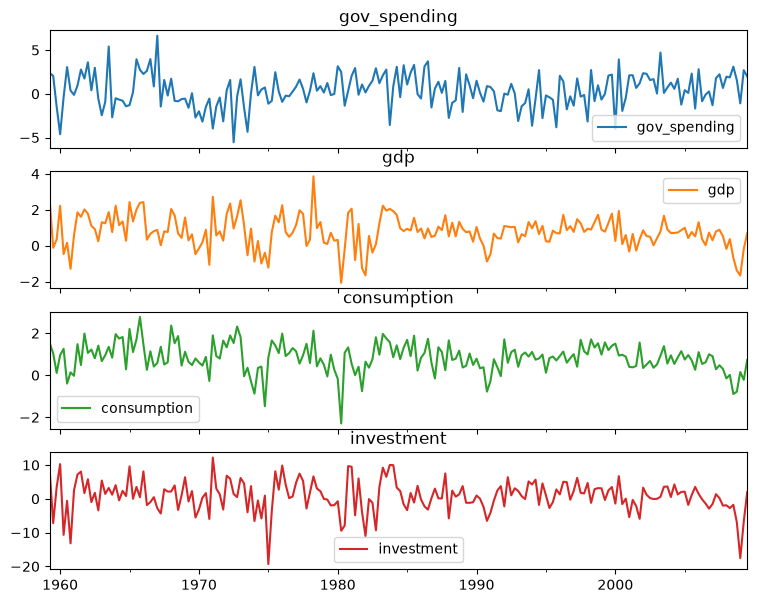

In [3]:
mdata = sm.datasets.macrodata.load_pandas().data

dates = mdata[["year", "quarter"]].astype(int).astype(str)
quarterly = dates["year"] + "Q" + dates["quarter"]
quarterly = dates_from_str(quarterly)

variables = ["realgovt", "realgdp", "realcons", "realinv"]
levels = mdata[variables]
levels.index = pd.DatetimeIndex(quarterly)

data = 100 * np.log(levels).diff().dropna()
data.columns = ["gov_spending", "gdp", "consumption", "investment"]
data.plot(subplots=True, figsize=(9, 7), title=list(data.columns));

## Identifying the shock

`LocalProjections` identifies the shock named by `shock_idx` using a recursive (Cholesky-style) scheme: the shock variable is assumed to be ordered first, i.e. contemporaneously exogenous to the other variables -- only *lagged* values of the other variables enter the regression, never their current-quarter values. This is the same assumption underlying Cholesky-orthogonalized VAR impulse responses (`IRAnalysis`), just estimated a different way.

For a government-spending shock this is the standard identification used in the fiscal-VAR literature (e.g. Blanchard and Perotti, 2002): spending decisions go through a legislative process with implementation lags, so it is plausible that government spending does not react *within* the same quarter to contemporaneous GDP, consumption or investment innovations, while those variables can react immediately to a spending shock. Because `gov_spending` is `data`'s first column, `shock_idx=0` (the default) encodes exactly this ordering.

In [4]:
lp = LocalProjections(
    data, shock_idx=0, lags=4, horizons=12, trend="c"
)
res = lp.fit()
res

LocalProjectionsResults(n_endog=4, n_shock=1, horizons=12, nobs=186)

`fit` runs $H+1=13$ separate regressions per response variable (one per horizon), each controlling for 4 lags of all four series. `res.irfs` holds the coefficient on the contemporaneous shock at every horizon -- the impulse response -- and `res.stderr` the matching Newey-West standard errors, with a bandwidth that grows with the horizon to account for the induced MA($h$) serial correlation.

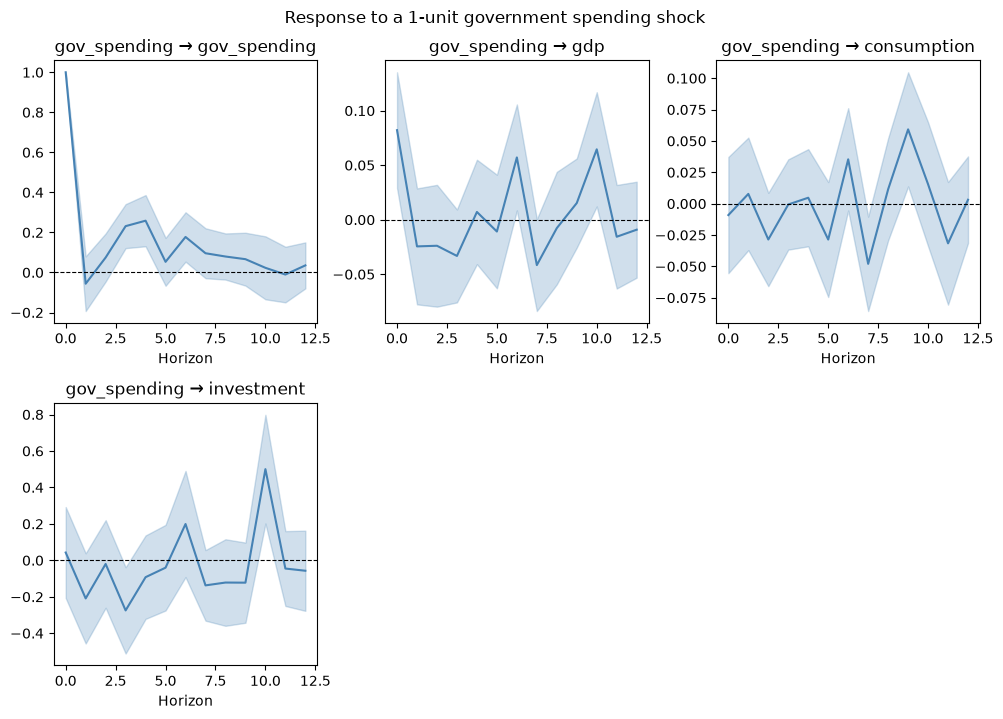

In [5]:
fig = res.plot_irfs(impulse="gov_spending", figsize=(10, 7))
fig.suptitle("Response to a 1-unit government spending shock", y=1.02);

The point estimates are noisy and the confidence bands are wide relative to the point estimates -- consistent with a large empirical literature finding that the output effects of fiscal shocks are hard to pin down precisely in aggregate, reduced-form time-series data of this kind. This is a realistic, not a cherry-picked, result: local projections are valued in part *because* they make it easy to see this kind of estimation uncertainty at every horizon, rather than only at the horizons a particular VAR happens to fit well.

## Cumulative effects

`cumulative_effects` sums the IRF across horizons, which is useful for reading off a rough cumulative-multiplier-style comparison: the cumulative GDP response relative to the cumulative spending response, horizon by horizon.

In [6]:
ce = res.cumulative_effects()
gdp = data.columns.get_loc("gdp")
gov = data.columns.get_loc("gov_spending")

cumulative_multiplier = ce[:, gdp, 0] / ce[:, gov, 0]
pd.Series(cumulative_multiplier, name="cumulative GDP / cumulative spending")

0     0.082120
1     0.061113
2     0.033205
3     0.000504
4     0.005140
5    -0.001955
6     0.031085
7     0.006796
8     0.002499
9     0.010137
10    0.042215
11    0.034611
12    0.029511
Name: cumulative GDP / cumulative spending, dtype: float64

## Comparison with a VAR

Because local projections and a Cholesky-identified VAR estimate impulse responses under the *same* identifying assumption when the shock variable is ordered first in both, they are estimating the same underlying object and should tell a broadly consistent story. They are not, however, forced to agree exactly in finite samples: a VAR estimates a single lag-$p$ model and propagates it forward through the companion form, while LP fits an independent regression at each horizon, so the two are different (both consistent) estimators of the same population impulse response, and some horizon-by-horizon disagreement is expected -- more so at longer horizons, where a low-order VAR's extrapolation and LP's flexibility can diverge the most.

One important bookkeeping difference: `VAR`'s orthogonalized IRFs (`orth_irfs`) report the response to a *one standard deviation* shock to the orthogonalized innovation, while `LocalProjections` reports the response to a *one unit* shock to the raw shock variable (its `irfs` are just the regression coefficient on the contemporaneous shock column). To compare them on the same footing we rescale the LP response by the reduced-form residual standard deviation of `gov_spending`.

/opt/hostedtoolcache/Python/3.14.7/x64/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


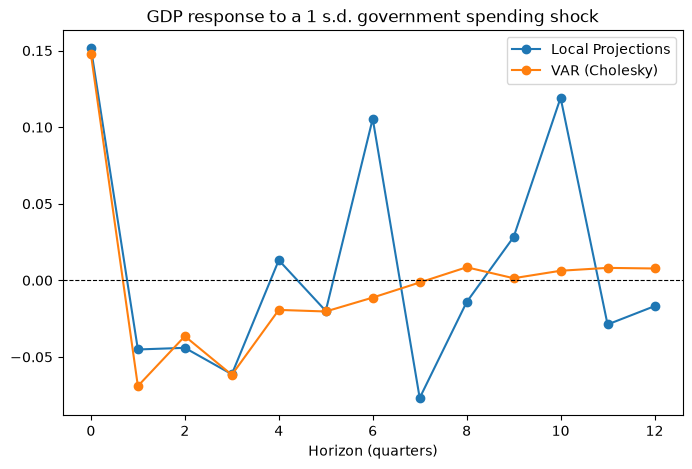

In [7]:
var_res = VAR(data).fit(4)
var_irf = var_res.irf(12)

shock_sd = np.sqrt(var_res.sigma_u.iloc[gov, gov])
lp_rescaled = shock_sd * res.irfs[:, gdp, 0]

h = np.arange(13)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h, lp_rescaled, marker="o", label="Local Projections")
ax.plot(h, var_irf.orth_irfs[:, gdp, gov], marker="o", label="VAR (Cholesky)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Horizon (quarters)")
ax.set_title("GDP response to a 1 s.d. government spending shock")
ax.legend();

The two methods broadly agree on sign and magnitude at short horizons and diverge somewhat further out, exactly as expected from the discussion above -- a useful sanity check to run whenever both a VAR and local projections are applicable to the same question.

## Further options

`LocalProjections` also supports:

- Multiple simultaneous shocks (`shock_idx` as a list) -- entered as ordinary simultaneous regressors, so they are only separately identified as shocks if those variables are themselves mutually contemporaneously exogenous.
- Exogenous controls via `exog` (entered contemporaneously, not lagged).
- `"n"`/`"c"`/`"ct"` trend specifications.
- Overriding the automatic Newey-West bandwidth via `nw_lags`.
- `conf_int(alpha)` for confidence intervals at any level, in addition to the default bands drawn by `plot_irfs`.